In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import scienceplots
import matplotlib as mpl
from tqdm import tqdm
from scipy.stats.mstats import ttest_onesamp

#mpl.rcParams.update(mpl.rcParamsDefault)
plt.style.use(['science','notebook'])
plt.rcParams['font.size'] = 18

colors = ["#FF595E","#8AC926","#1982C4","black"]

In [3]:
def compute_IBs_and_errors(imbs_X_to_Y, imbs_Y_to_X, correction=True, confidence=0.99):
    '''imbs_X_to_Y and imbs_Y_to_X have shape (n_seeds, n_taus, n_alphas)
    '''

    assert imbs_X_to_Y.shape == imbs_Y_to_X.shape, "Error: shapes of two inputs do not match!"
    n_indep_realizations = imbs_X_to_Y.shape[0]
    n_taus = imbs_X_to_Y.shape[1]
    
    # compute average IGs as a function of tau and alpha
    IB_X_to_Y_avg = imbs_X_to_Y.mean(axis=0)
    IB_Y_to_X_avg = imbs_Y_to_X.mean(axis=0)        

    # extract global alpha minimized for each tau
    alphas_min_X_to_Y = np.argmin(IB_X_to_Y_avg, axis=-1)
    alphas_min_Y_to_X = np.argmin(IB_Y_to_X_avg, axis=-1)

    # compute IGs as a function of tau
    IBG_X_to_Y_avg = IB_X_to_Y_avg[np.arange(n_taus),alphas_min_X_to_Y]
    IBG_Y_to_X_avg = IB_Y_to_X_avg[np.arange(n_taus),alphas_min_Y_to_X]

    IB_Y_to_Y_avg =  IB_X_to_Y_avg[:,0]
    IB_X_to_X_avg =  IB_Y_to_X_avg[:,0]

    assert IBG_X_to_Y_avg.shape == IB_Y_to_Y_avg.shape, "Error: shapes of two outputs do not match!"
    
    return (IB_Y_to_Y_avg, IB_X_to_X_avg, 
            IBG_X_to_Y_avg, IBG_Y_to_X_avg, 
            alphas_min_X_to_Y, alphas_min_Y_to_X)

In [4]:
def compute_gains_and_errors(imbs_X_to_Y, imbs_Y_to_X, correction=True, confidence=0.99):
    '''imbs_X_to_Y and imbs_Y_to_X have shape (n_seeds, n_taus, n_alphas)
    '''

    assert imbs_X_to_Y.shape == imbs_Y_to_X.shape, "Error: shapes of two inputs do not match!"
    n_indep_realizations = imbs_X_to_Y.shape[0]
    n_taus = imbs_X_to_Y.shape[1]
    
    # compute IGs as a function of tau and alpha
    gain_X_to_Y_indep = 100*(imbs_X_to_Y[:,:,0,np.newaxis]-imbs_X_to_Y[:,:,:]) \
                                    / imbs_X_to_Y[:,:,0,np.newaxis]
    gain_Y_to_X_indep = 100*(imbs_Y_to_X[:,:,0,np.newaxis]-imbs_Y_to_X[:,:,:]) \
                                    / imbs_Y_to_X[:,:,0,np.newaxis]

    # compute average IGs as a function of tau and alpha
    gain_X_to_Y_avg = gain_X_to_Y_indep.mean(axis=0)
    gain_Y_to_X_avg = gain_Y_to_X_indep.mean(axis=0)        

    # extract global alpha minimized for each tau
    alphas_max_X_to_Y = np.argmax(gain_X_to_Y_avg, axis=-1)
    alphas_max_Y_to_X = np.argmax(gain_Y_to_X_avg, axis=-1)

    # compute IGs as a function of tau
    gain_X_to_Y_avg = gain_X_to_Y_avg[np.arange(n_taus),alphas_max_X_to_Y]
    gain_Y_to_X_avg = gain_Y_to_X_avg[np.arange(n_taus),alphas_max_Y_to_X] 

    # compute errors associated to IGs as a function of tau (standard error of the mean)
    error_X_to_Y = gain_X_to_Y_indep.std(axis=0)[np.arange(n_taus),alphas_max_X_to_Y] \
                    / np.sqrt(n_indep_realizations)
    error_Y_to_X = gain_Y_to_X_indep.std(axis=0)[np.arange(n_taus),alphas_max_Y_to_X] \
                    / np.sqrt(n_indep_realizations)

    # test statistical confidence according to one-tail t-test
    ttest_X_to_Y = ttest_onesamp(
        gain_X_to_Y_indep[:,np.arange(n_taus),alphas_max_X_to_Y], popmean=0, axis=0, alternative='greater'
    )
    ttest_Y_to_X = ttest_onesamp(
        gain_X_to_Y_indep[:,np.arange(n_taus),alphas_max_X_to_Y], popmean=0, axis=0, alternative='greater'
    )
    mask_X_to_Y = (ttest_X_to_Y.pvalue.data < 1. - confidence)
    mask_Y_to_X = (ttest_Y_to_X.pvalue.data < 1. - confidence)
    
    # correction (set to 0 those IGs for which Imbalance(alpha=0) > 1)
    if correction:
        imb_X_to_Y_avg_alpha0 = imbs_X_to_Y.mean(axis=0)[:,0]
        taus_correction_X_to_Y = np.where(imb_X_to_Y_avg_alpha0 > 1.)
        gain_X_to_Y_avg[taus_correction_X_to_Y] = 0.
        error_X_to_Y[taus_correction_X_to_Y] = 0.
        mask_X_to_Y[taus_correction_X_to_Y] = False
        
        imb_Y_to_X_avg_alpha0 = imbs_Y_to_X.mean(axis=0)[:,0]
        taus_correction_Y_to_X = np.where(imb_Y_to_X_avg_alpha0 > 1.)
        gain_Y_to_X_avg[taus_correction_Y_to_X] = 0.
        error_Y_to_X[taus_correction_Y_to_X] = 0.
        mask_Y_to_X[taus_correction_X_to_Y] = False

    return (gain_X_to_Y_avg, gain_Y_to_X_avg, 
            error_X_to_Y, error_Y_to_X, 
            alphas_max_X_to_Y, alphas_max_Y_to_X,
            mask_X_to_Y, mask_Y_to_X)

In [5]:
plt.rcParams['font.size'] = 18

colors = ["#FF595E","#8AC926","#1982C4","black"]


In [6]:
def make_plot(
        info_imbalances_X_to_Y, info_imbalances_Y_to_X, 
        label_X_to_Y, label_Y_to_X, label_Y_to_Y, label_X_to_X,
        xlim = 20,
        nseed = 50,
        name_tpl = ''
):

    intput_timestep = 400 # in ps
    final_time = 30000 # in psep // 
    taus_plot_factor = 0.01
    final_time_index = 248
    taus_plot = taus #[:final_time_index]
    
    # compute mean IBS and gains
    (IB_Y_to_Y_avg, IB_X_to_X_avg, 
            IBG_X_to_Y_avg, IBG_Y_to_X_avg, 
            alphas_min_X_to_Y, alphas_min_Y_to_X) = (
                compute_IBs_and_errors(info_imbalances_X_to_Y[:,:final_time_index], 
                                         info_imbalances_Y_to_X[:,:final_time_index])
            )
    
    # compute IGs, errors, and confidence masks
    (gain_X_to_Y_avg, gain_Y_to_X_avg, error_X_to_Y, error_Y_to_X, 
     alphas_X_to_Y, alphas_Y_to_X,mask_X_to_Y, mask_Y_to_X) = (
                compute_gains_and_errors(info_imbalances_X_to_Y[:,:final_time_index], 
                                         info_imbalances_Y_to_X[:,:final_time_index], correction=True)
    )

    # plots
    plt.rcParams['font.size'] = 18
    plt.figure(figsize=(14,5))

    plt.plot(taus_plot * taus_plot_factor, IB_Y_to_Y_avg, '-', label=label_Y_to_Y, 
            alpha=1, linewidth=2, color=colors[0])
    plt.plot(taus_plot * taus_plot_factor, IB_X_to_X_avg, '-', label=label_X_to_X,
            alpha=1, linewidth=2, color=colors[1])

    plt.plot(taus_plot * taus_plot_factor, IBG_X_to_Y_avg, '-', label=f"{label_Y_to_Y}_gain",
            alpha=1, linewidth=2, color=colors[2])
    plt.plot(taus_plot * taus_plot_factor, IBG_Y_to_X_avg, '-', label=f"{label_X_to_X}_gain",
            alpha=1, linewidth=2, color=colors[3])
    
    plt.legend() #loc='center left', bbox_to_anchor=(1, 0.5))
    plt.title(f"$E = {E}$, $\\tau_e = {tau_e*10:.1f}$ fs, $k = {k}, Nseed = {nseed}$")
    plt.xlabel("$\\tau$ [ps]")
    plt.ylabel("Imformation Imbalance and Gain [-]")
    plt.xlim([-0.5, xlim])
    #plt.savefig("fig_IG_vs_tau_causality.pdf", dpi=300, bbox_inches="tight")
    plt.savefig(f"{name_tpl}_Info-Imb.png")
    plt.show()
    plt.close()
    
    plt.rcParams['font.size'] = 18
    plt.figure(figsize=(14,5))
    plt.hist(alphas_min_X_to_Y, bins=100, label=label_X_to_Y, alpha=0.5, color=colors[0])
    plt.hist(alphas_min_Y_to_X, bins=100, label=label_Y_to_X, alpha=0.5, color=colors[1])
    plt.legend() #loc='center left', bbox_to_anchor=(1, 0.5))
    plt.title(f"$E = {E}$, $\\tau_e = {tau_e*10:.1f}$ fs, $k = {k}, Nseed = {nseed}$")
    plt.xlabel("$\\alpha$")
    plt.ylabel("Frequency")
    plt.savefig(f"{name_tpl}_min-alpha-frequency.png")
    plt.show()
    plt.close()

    
    plt.figure(figsize=(14,5))

    plt.plot(taus_plot*taus_plot_factor, gain_X_to_Y_avg, '-', label=label_X_to_Y, 
            alpha=0.5, linewidth=2, color=colors[0])
    plt.plot(taus_plot*taus_plot_factor, gain_Y_to_X_avg, '-', label=label_Y_to_X,
            alpha=0.5, linewidth=2, color=colors[1])

    plt.plot(taus_plot[mask_X_to_Y]*taus_plot_factor, gain_X_to_Y_avg[mask_X_to_Y], 
            'o', color=colors[0], markersize=5)
    plt.plot(taus_plot[mask_Y_to_X]*taus_plot_factor, gain_Y_to_X_avg[mask_Y_to_X], 
            's', color=colors[1], markersize=4)

    plt.fill_between(taus_plot*taus_plot_factor, gain_X_to_Y_avg - error_X_to_Y, 
                                    gain_X_to_Y_avg + error_X_to_Y, alpha=0.2, color=colors[0])
    plt.fill_between(taus_plot*taus_plot_factor, gain_Y_to_X_avg - error_Y_to_X, 
                                    gain_Y_to_X_avg + error_Y_to_X, alpha=0.2, color=colors[1])

    plt.legend() #loc='center left', bbox_to_anchor=(1, 0.5))
    plt.title(f"$E = {E}$, $\\tau_e = {tau_e*10:.1f}$ fs, $k = {k}, Nseed = {nseed}$")
    plt.xlabel("$\\tau$ [ps]")
    plt.ylabel("Imbalance Gain [%]")
    plt.xlim([-0.5, xlim])
    #plt.savefig("fig_IG_vs_tau_causality.pdf", dpi=300, bbox_inches="tight")
    plt.savefig(f"{name_tpl}_Imb-Gain.png")
    plt.show()
    plt.close()
    

    plt.figure(figsize=(14,5))
    plt.hist(alphas_X_to_Y, bins=100, label=label_X_to_Y, alpha=0.5, color=colors[0])
    plt.hist(alphas_Y_to_X, bins=100, label=label_Y_to_X, alpha=0.5, color=colors[1])
    plt.legend() #loc='center left', bbox_to_anchor=(1, 0.5))
    plt.title(f"$E = {E}$, $\\tau_e = {tau_e*10:.1f}$ fs, $k = {k}, Nseed = {nseed}$")
    plt.xlabel("$\\alpha$")
    plt.ylabel("Frequency")
    plt.savefig(f"{name_tpl}_alpha-frequency.png")
    plt.show()


In [7]:
# read files dipole <-> environment, forward time
k = 20
taus = np.arange(0,4960,20) #np.arange(0,4440+20,20)
seeds = np.arange(1,50+1)
#trajs = np.arange(1,30+1)
E = 50
tau_e = 1
alphasize = 200

info_imbalances_ref_to_1st = np.zeros((len(seeds),len(taus),alphasize))
info_imbalances_1st_to_ref = np.zeros((len(seeds),len(taus),alphasize))
info_imbalances_ref_to_2nd = np.zeros((len(seeds),len(taus),alphasize))
info_imbalances_2nd_to_ref = np.zeros((len(seeds),len(taus),alphasize))
info_imbalances_1st_to_2nd = np.zeros((len(seeds),len(taus),alphasize))
info_imbalances_2nd_to_1st = np.zeros((len(seeds),len(taus),alphasize))
info_imbalances_ref_to_total = np.zeros((len(seeds),len(taus),alphasize))
info_imbalances_total_to_ref = np.zeros((len(seeds),len(taus),alphasize))
info_imbalances_1st_to_total = np.zeros((len(seeds),len(taus),alphasize))
info_imbalances_total_to_1st = np.zeros((len(seeds),len(taus),alphasize))
info_imbalances_2nd_to_total = np.zeros((len(seeds),len(taus),alphasize))
info_imbalances_total_to_2nd = np.zeros((len(seeds),len(taus),alphasize))
info_imbalances_ref_to_totalc = np.zeros((len(seeds),len(taus),alphasize))
info_imbalances_totalc_to_ref = np.zeros((len(seeds),len(taus),alphasize))
info_imbalances_1st_to_totalc = np.zeros((len(seeds),len(taus),alphasize))
info_imbalances_totalc_to_1st = np.zeros((len(seeds),len(taus),alphasize))
info_imbalances_2nd_to_totalc = np.zeros((len(seeds),len(taus),alphasize))
info_imbalances_totalc_to_2nd = np.zeros((len(seeds),len(taus),alphasize))

for i, seed in enumerate(seeds):
    for j, tau in enumerate(taus):

        (info_imbalances_ref_to_1st[i,j], info_imbalances_1st_to_ref[i,j], 
        info_imbalances_ref_to_2nd[i,j], info_imbalances_2nd_to_ref[i,j],
        info_imbalances_1st_to_2nd[i,j], info_imbalances_2nd_to_1st[i,j],
        info_imbalances_ref_to_total[i,j], info_imbalances_total_to_ref[i,j],
        info_imbalances_1st_to_total[i,j], info_imbalances_total_to_1st[i,j],
        info_imbalances_2nd_to_total[i,j], info_imbalances_total_to_2nd[i,j],
        info_imbalances_ref_to_totalc[i,j], info_imbalances_totalc_to_ref[i,j],
        info_imbalances_1st_to_totalc[i,j], info_imbalances_totalc_to_1st[i,j],
        info_imbalances_2nd_to_totalc[i,j], info_imbalances_totalc_to_2nd[i,j],
        ) = (
            pickle.load(open(f"pickles_imb/imb_seed{seed}_tau{tau}_k{k}.p","rb"))
        )

### ref dipole vs 1st shell

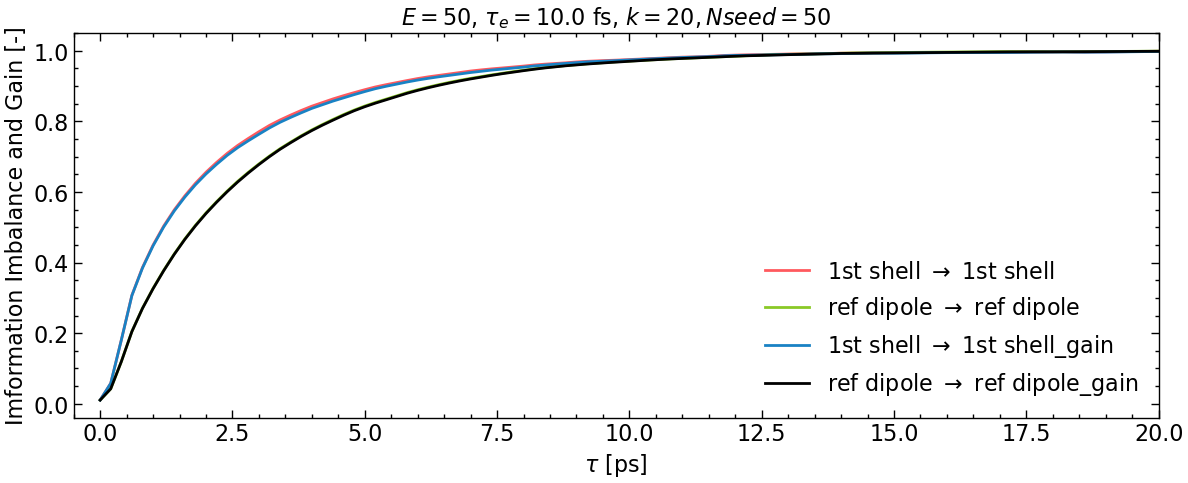

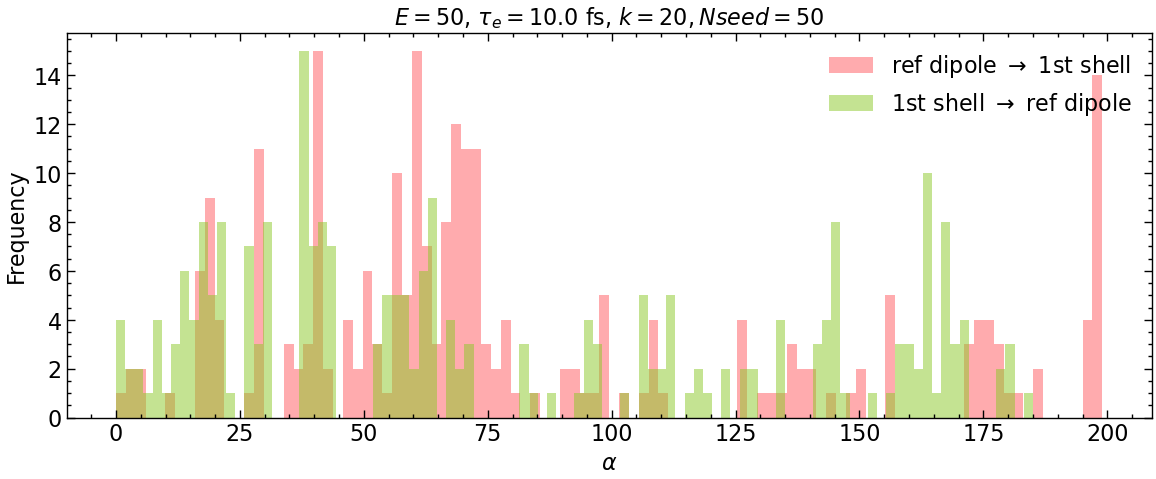

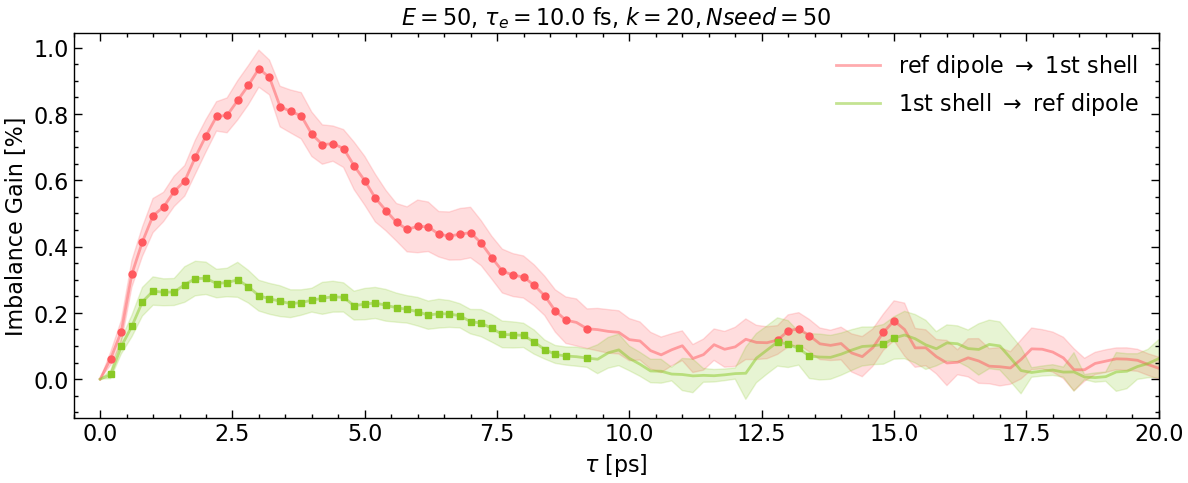

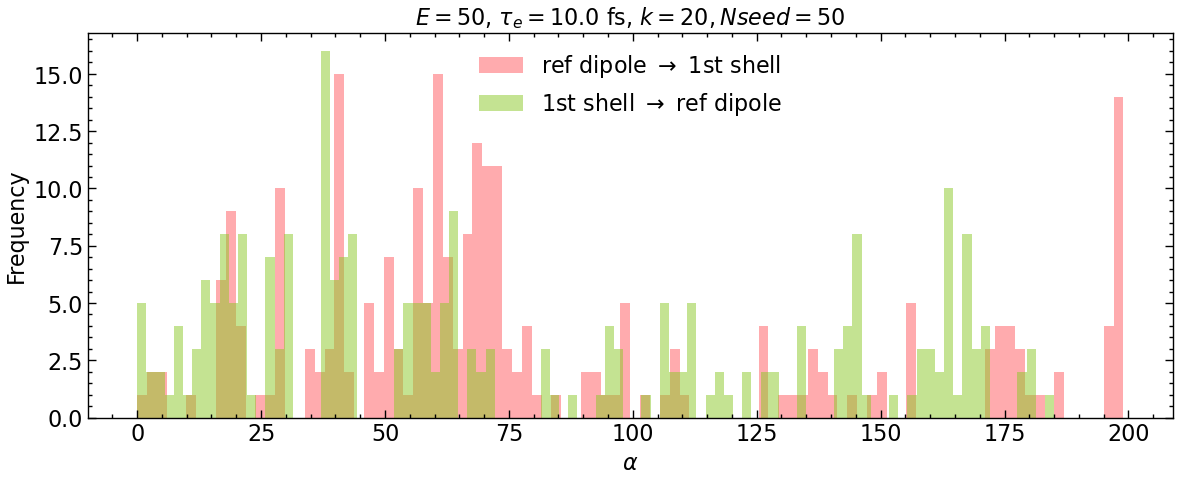

In [8]:
label_xy = "ref dipole $\\rightarrow$ 1st shell"
label_yx = "1st shell $\\rightarrow$ ref dipole"
label_yy = "1st shell $\\rightarrow$ 1st shell"
label_xx = "ref dipole $\\rightarrow$ ref dipole"


make_plot(info_imbalances_ref_to_1st, info_imbalances_1st_to_ref, label_xy, label_yx, label_yy, label_xx, nseed = len(seeds), name_tpl = "ref-1st_300K_1B_ns")

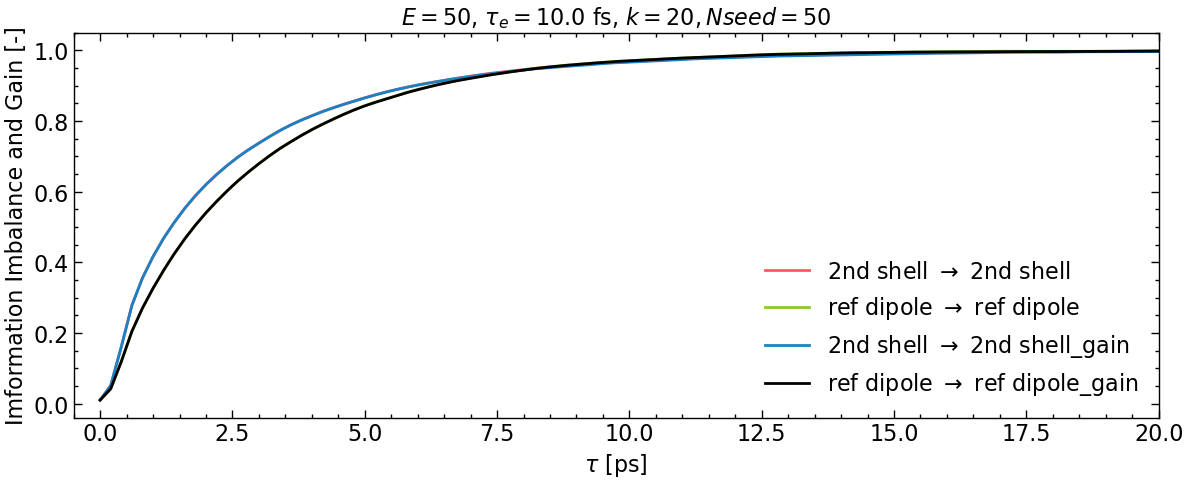

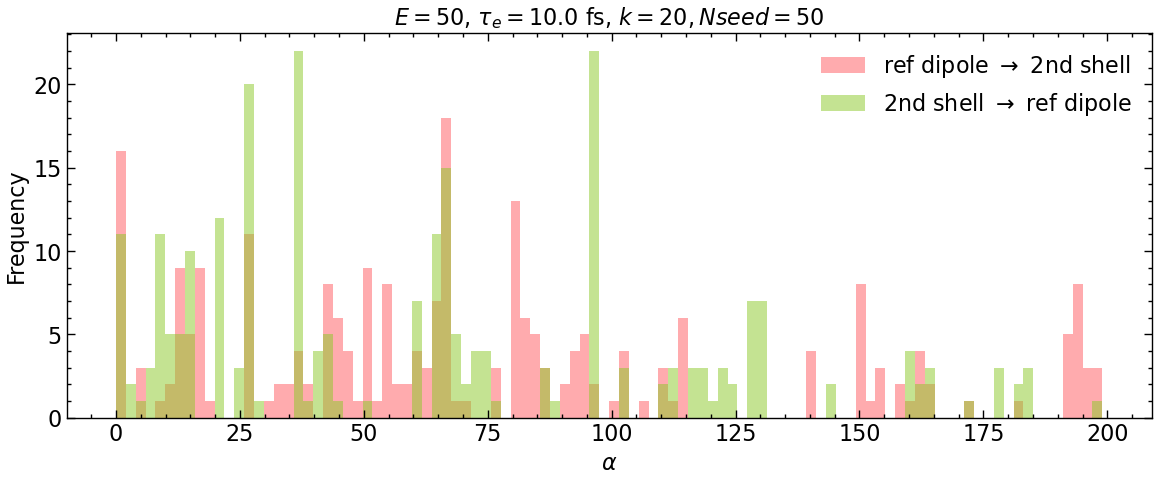

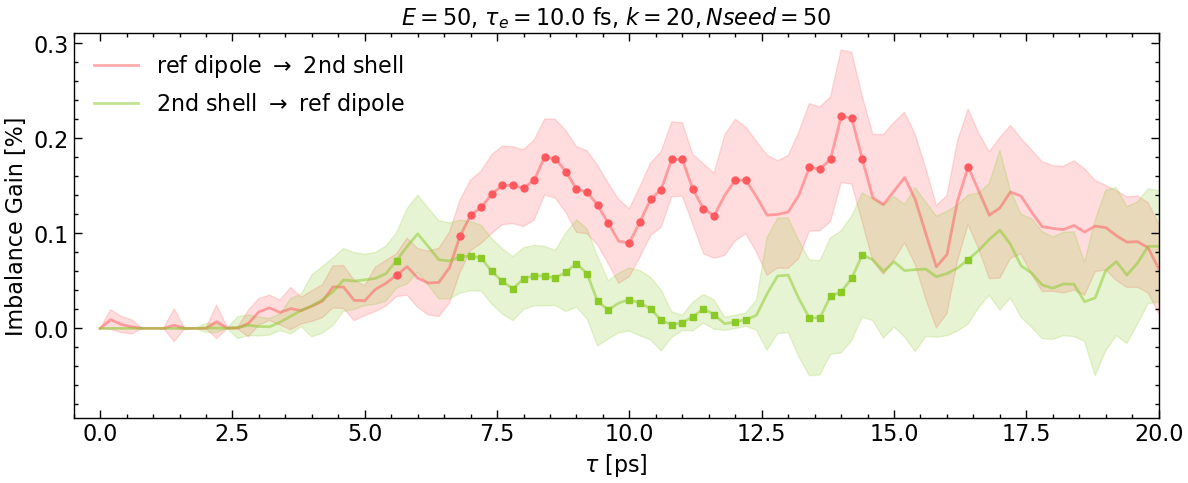

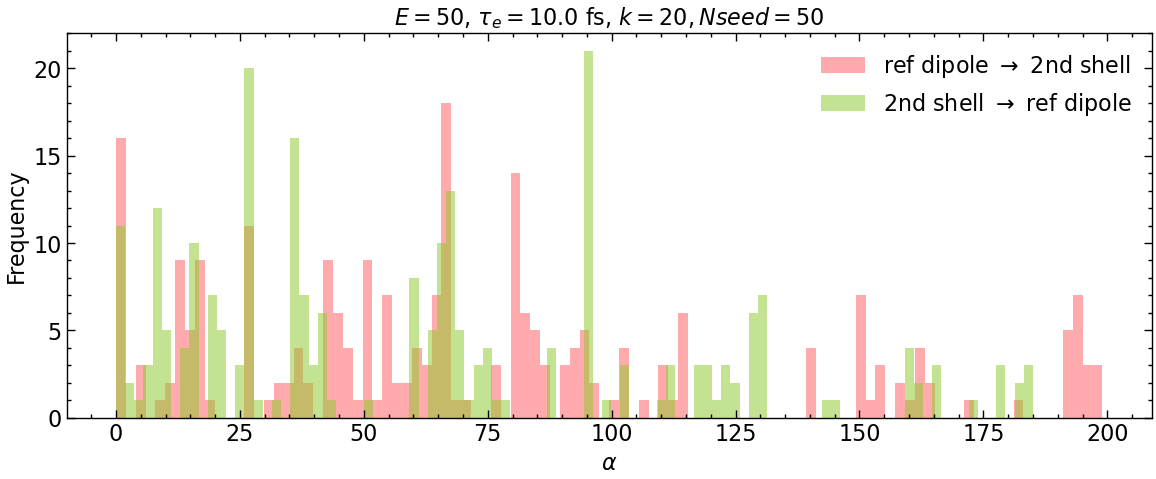

In [9]:
label_xy = "ref dipole $\\rightarrow$ 2nd shell"
label_yx = "2nd shell $\\rightarrow$ ref dipole"
label_yy = "2nd shell $\\rightarrow$ 2nd shell"
label_xx = "ref dipole $\\rightarrow$ ref dipole"


make_plot(info_imbalances_ref_to_2nd, info_imbalances_2nd_to_ref, label_xy, label_yx, label_yy, label_xx, nseed = len(seeds), name_tpl = "ref_2nd_300K_1B_ns")

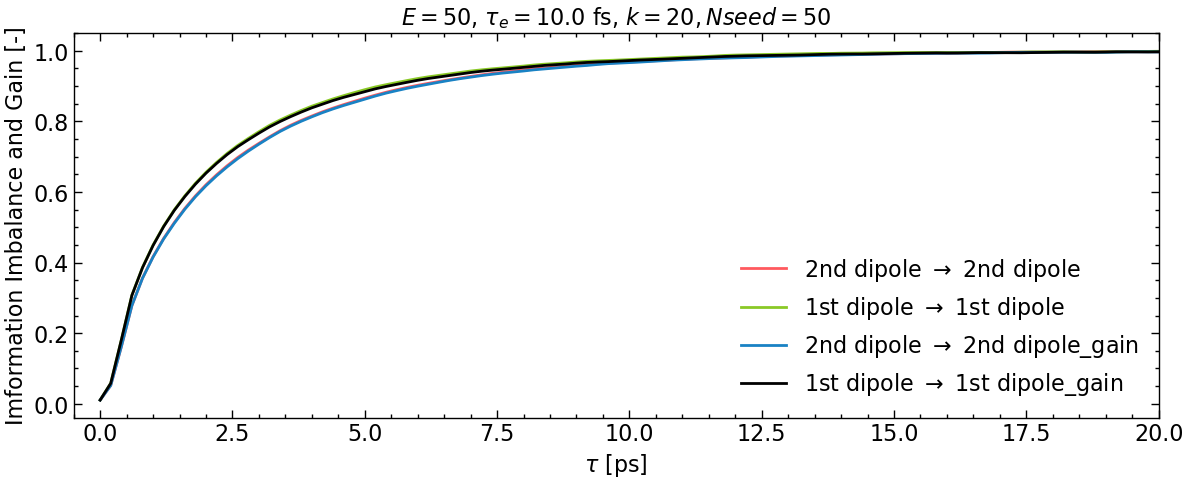

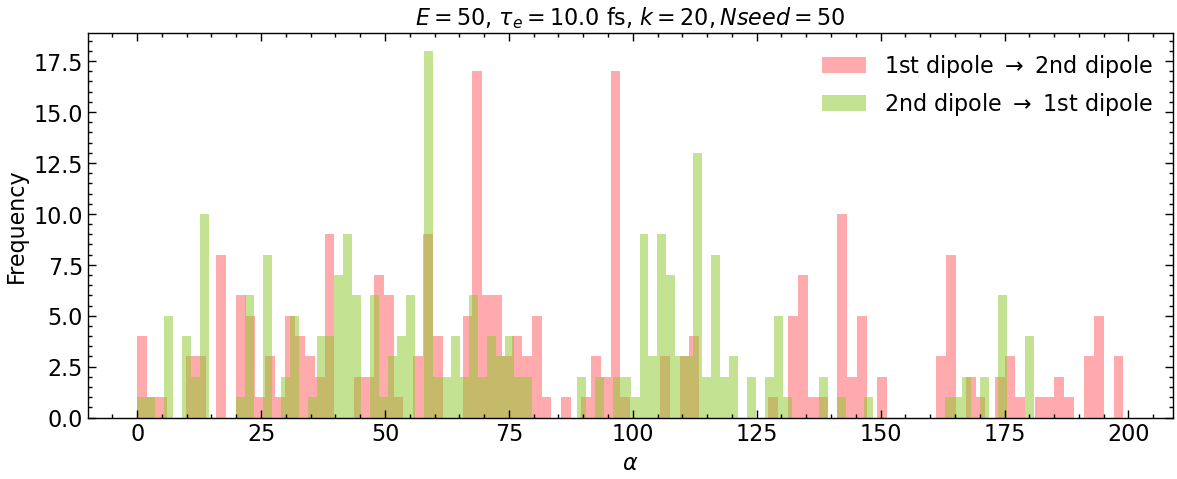

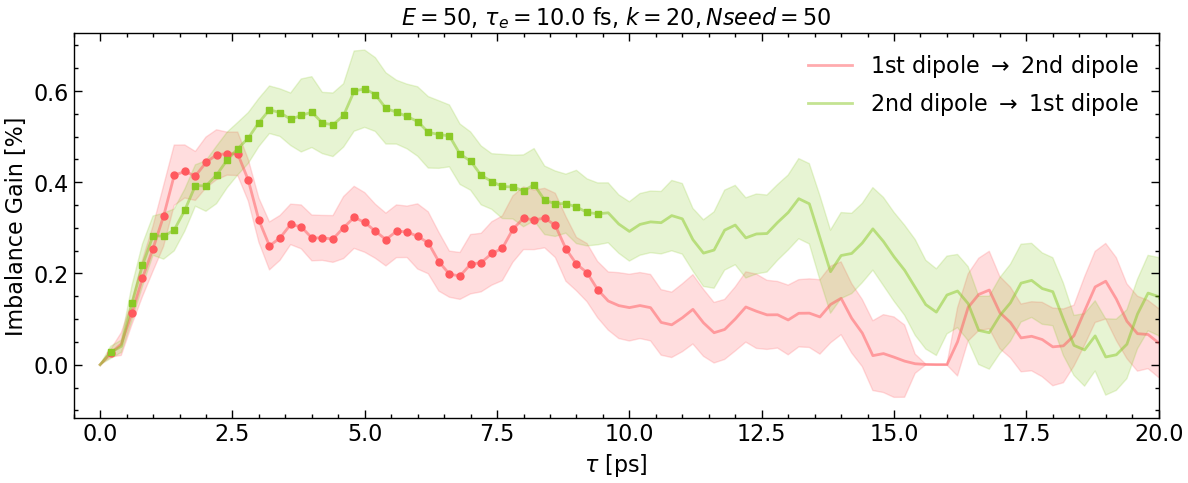

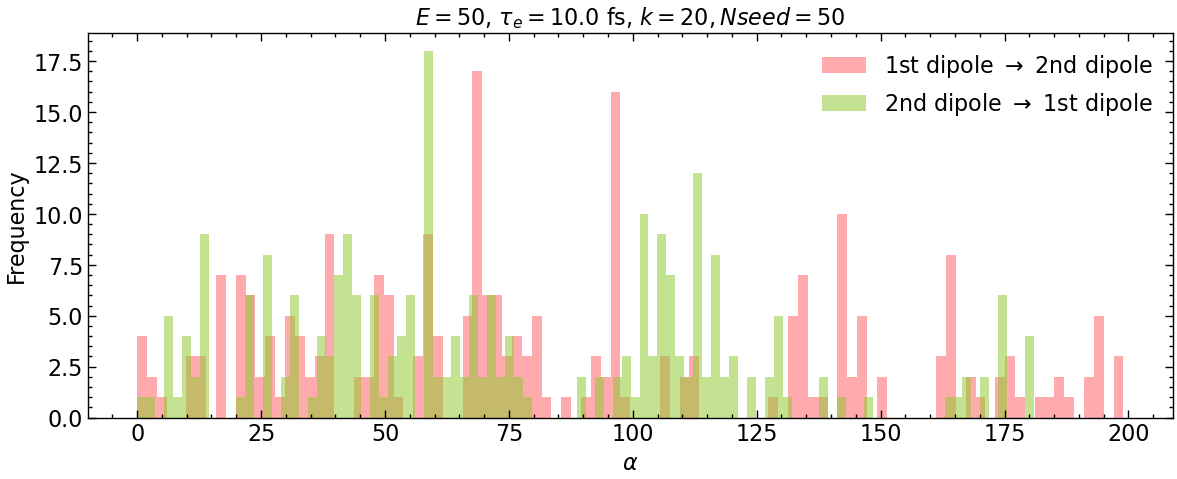

In [10]:
label_xy = "1st dipole $\\rightarrow$ 2nd dipole"
label_yx = "2nd dipole $\\rightarrow$ 1st dipole"
label_yy = "2nd dipole $\\rightarrow$ 2nd dipole"
label_xx = "1st dipole $\\rightarrow$ 1st dipole"


make_plot(info_imbalances_1st_to_2nd, info_imbalances_2nd_to_1st, label_xy, label_yx, label_yy, label_xx, nseed = len(seeds), name_tpl = "1st_2nd_300K_1B_ns")

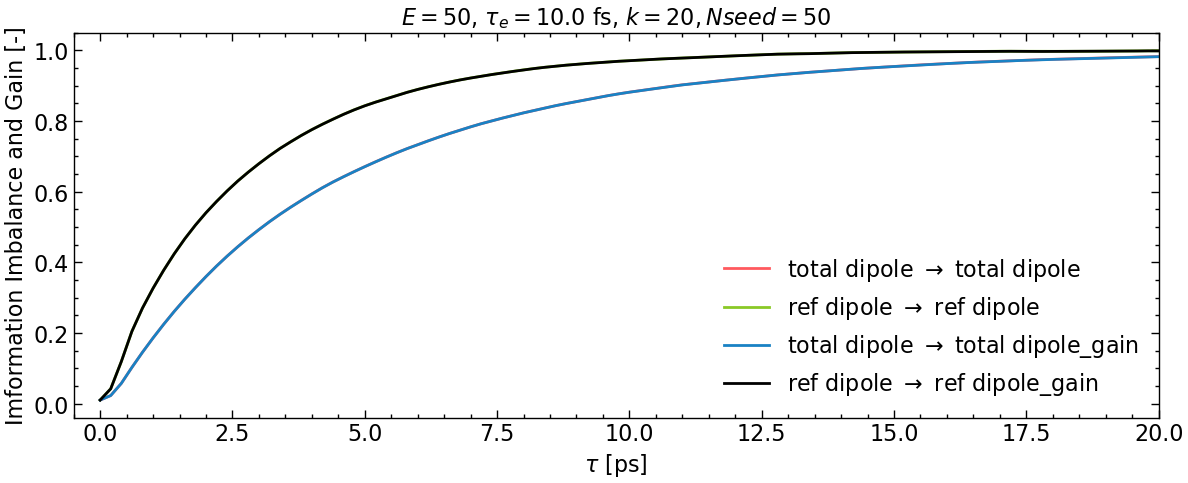

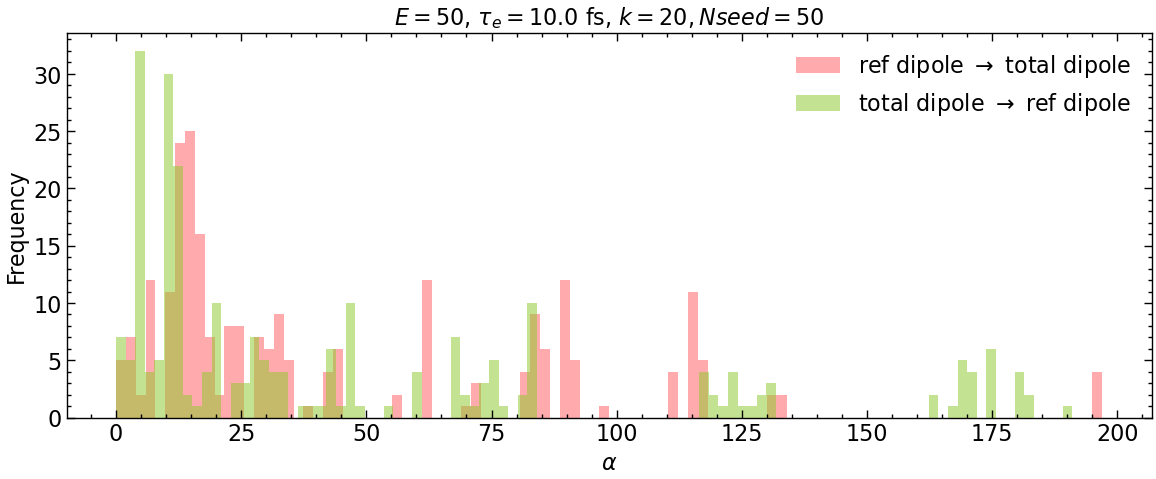

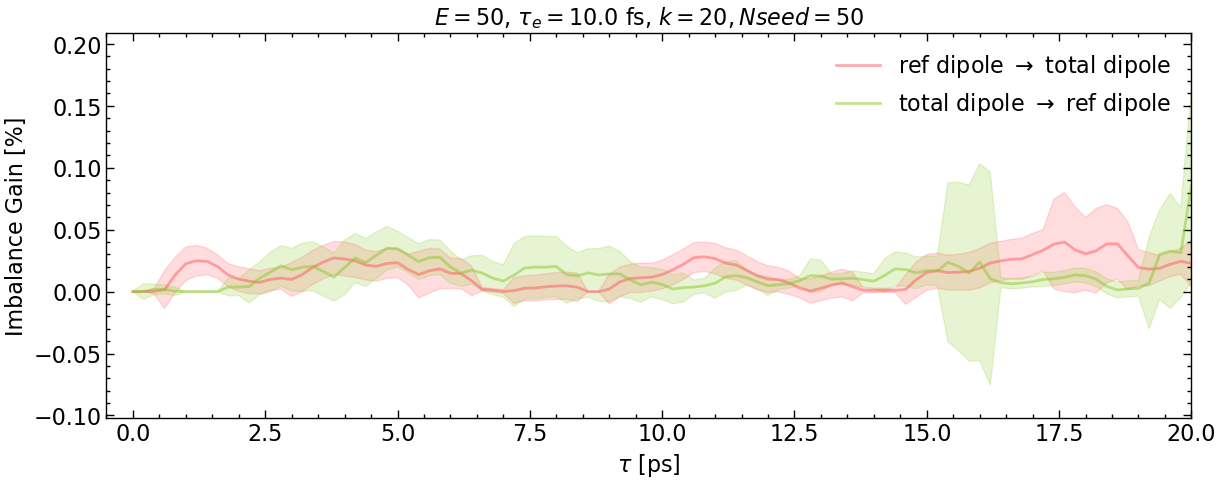

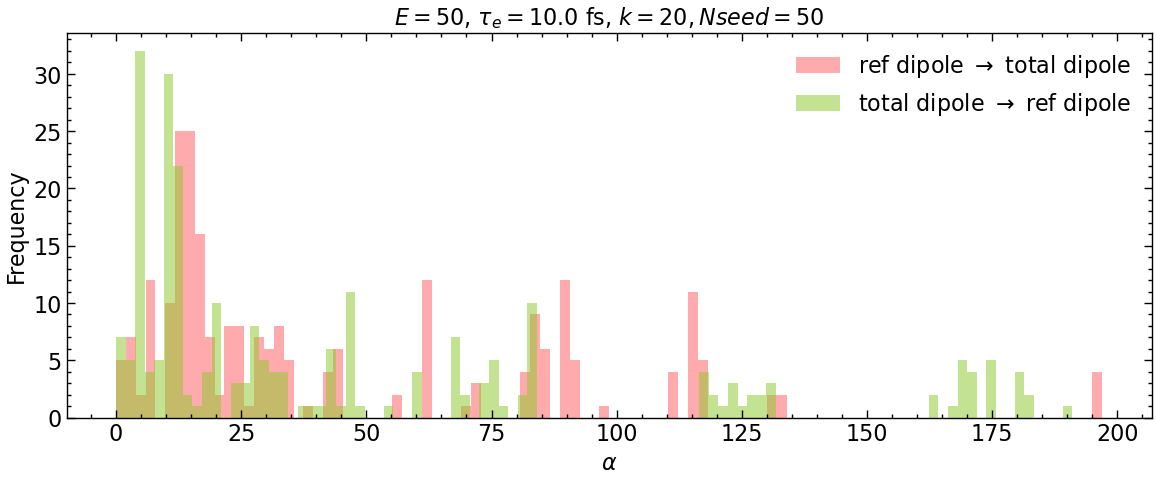

In [11]:
label_xy = "ref dipole $\\rightarrow$ total dipole"
label_yx = "total dipole $\\rightarrow$ ref dipole"
label_yy = "total dipole $\\rightarrow$ total dipole"
label_xx = "ref dipole $\\rightarrow$ ref dipole"


make_plot(info_imbalances_ref_to_total, info_imbalances_total_to_ref, label_xy, label_yx, label_yy, label_xx, nseed = len(seeds), name_tpl = "ref_total_300K_1B_ns")

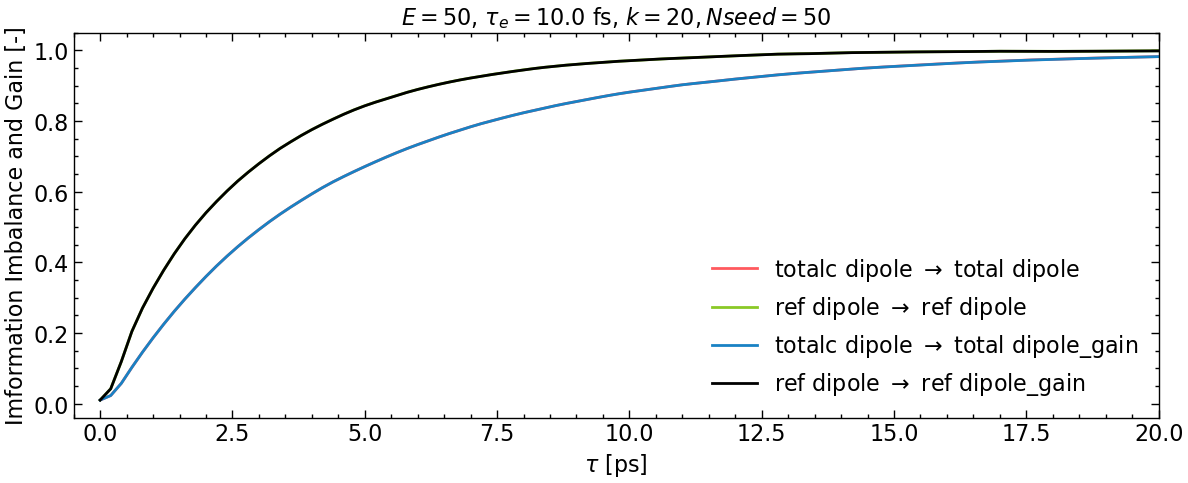

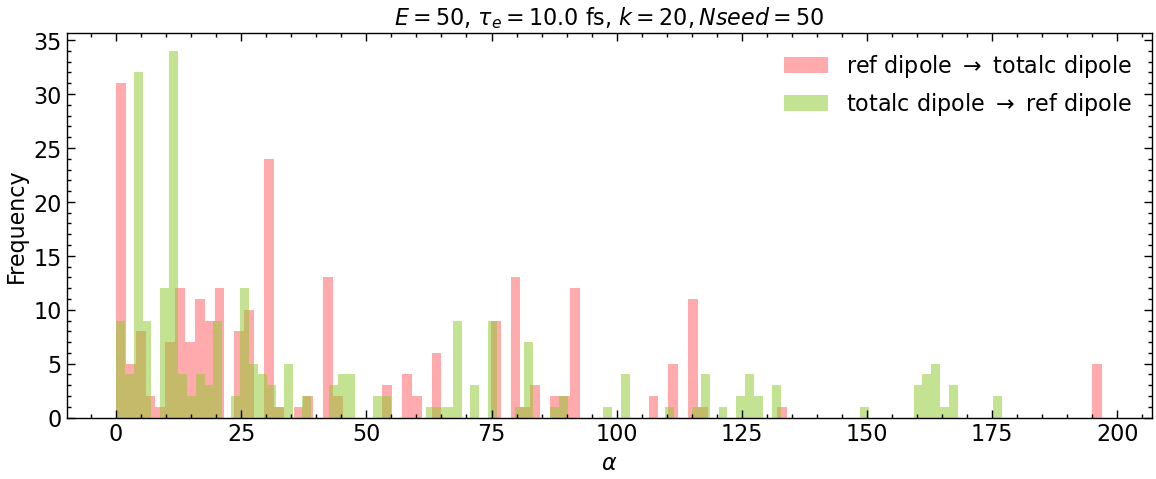

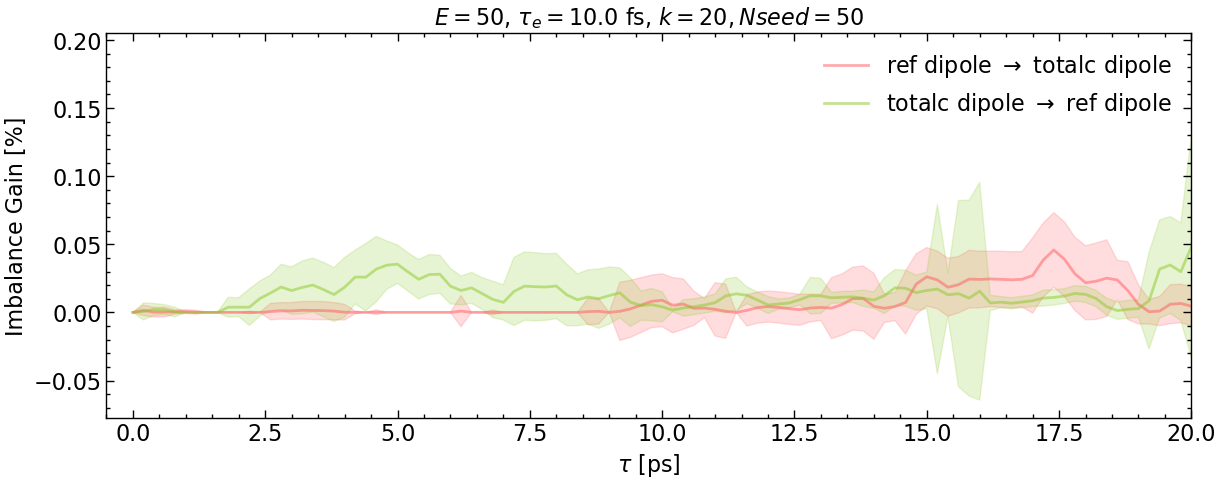

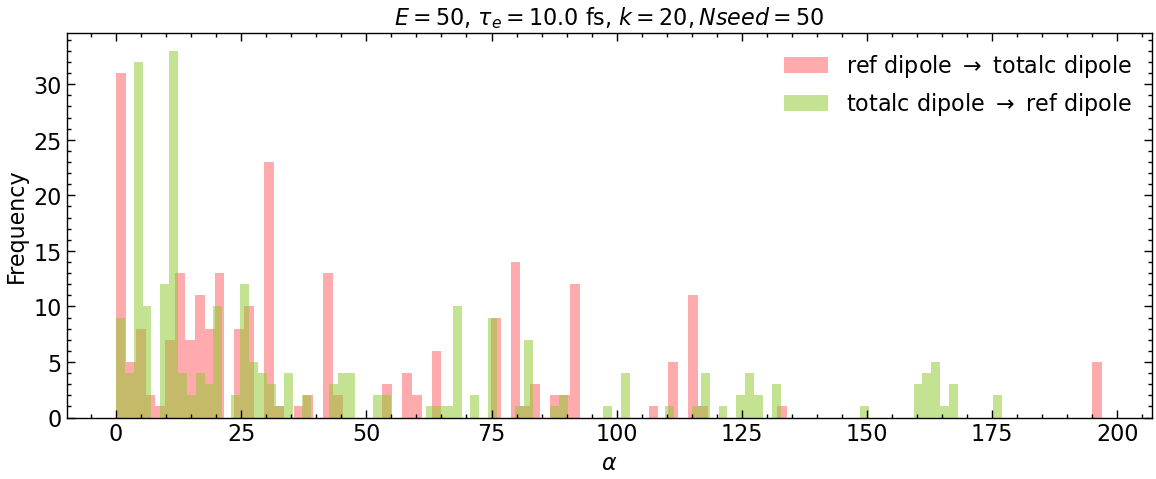

In [12]:
label_xy = "ref dipole $\\rightarrow$ totalc dipole"
label_yx = "totalc dipole $\\rightarrow$ ref dipole"
label_yy = "totalc dipole $\\rightarrow$ total dipole"
label_xx = "ref dipole $\\rightarrow$ ref dipole"


make_plot(info_imbalances_ref_to_totalc, info_imbalances_totalc_to_ref, label_xy, label_yx, label_yy, label_xx, nseed = len(seeds), name_tpl = "ref_totalc_300K_1B_ns")

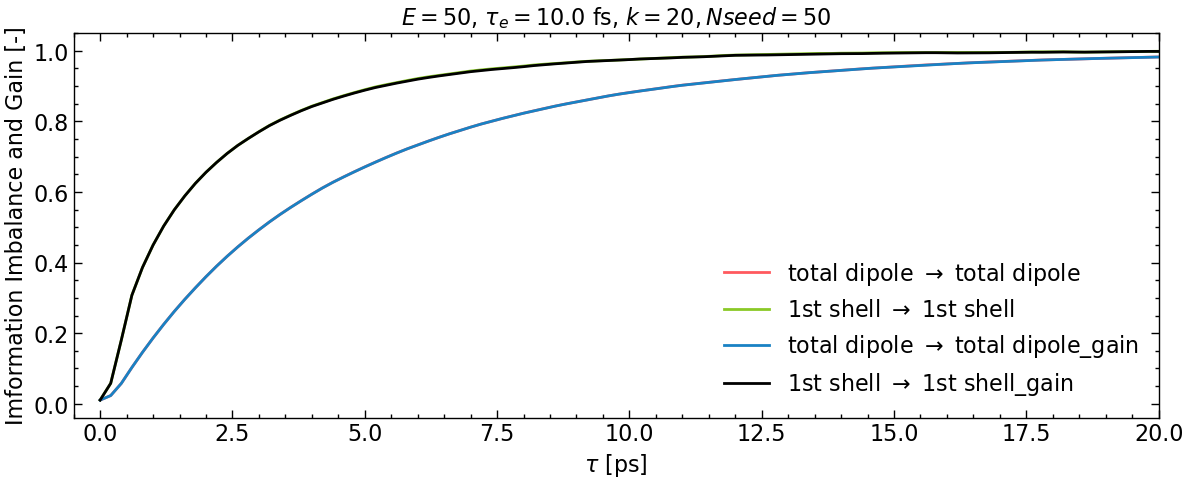

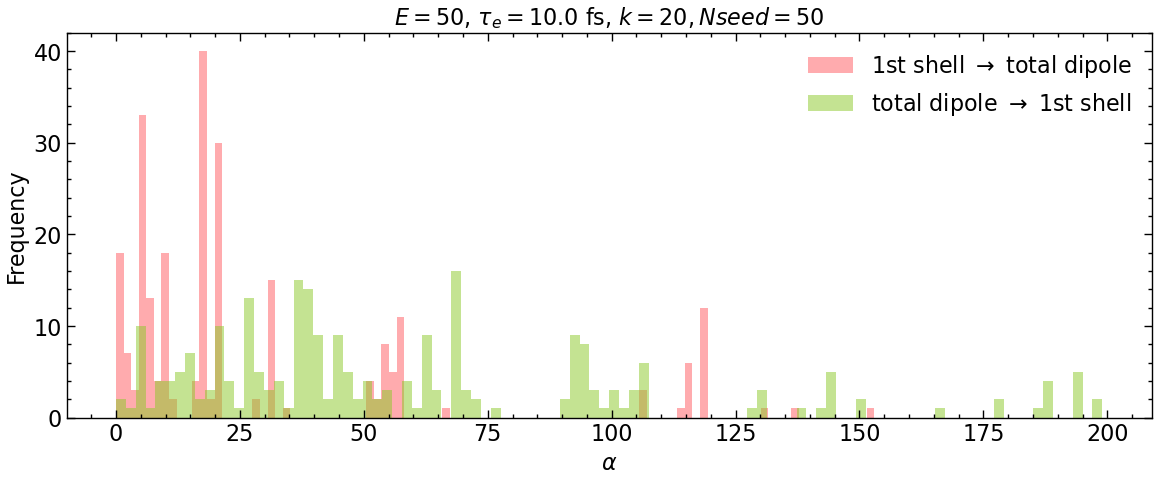

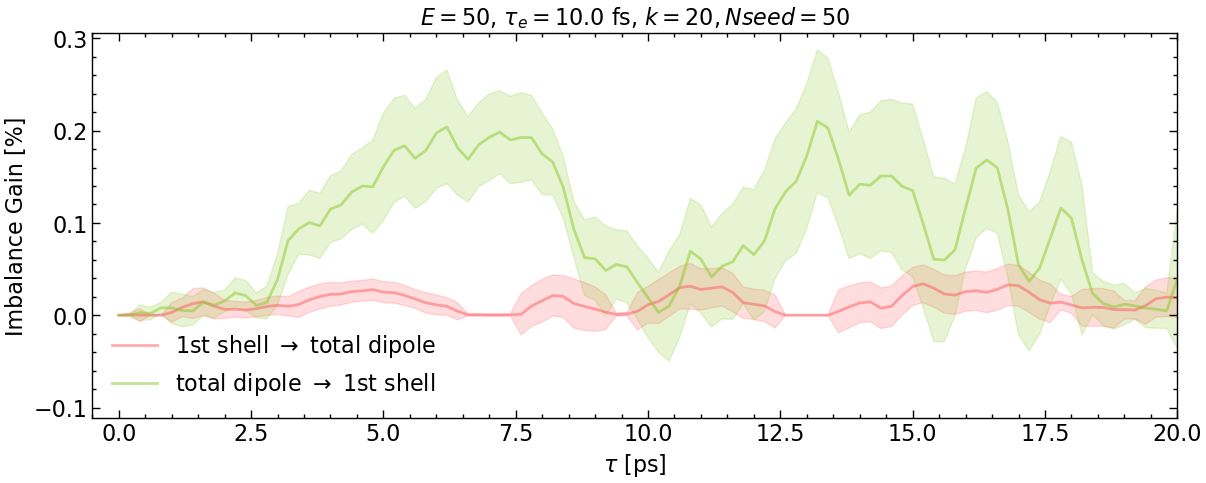

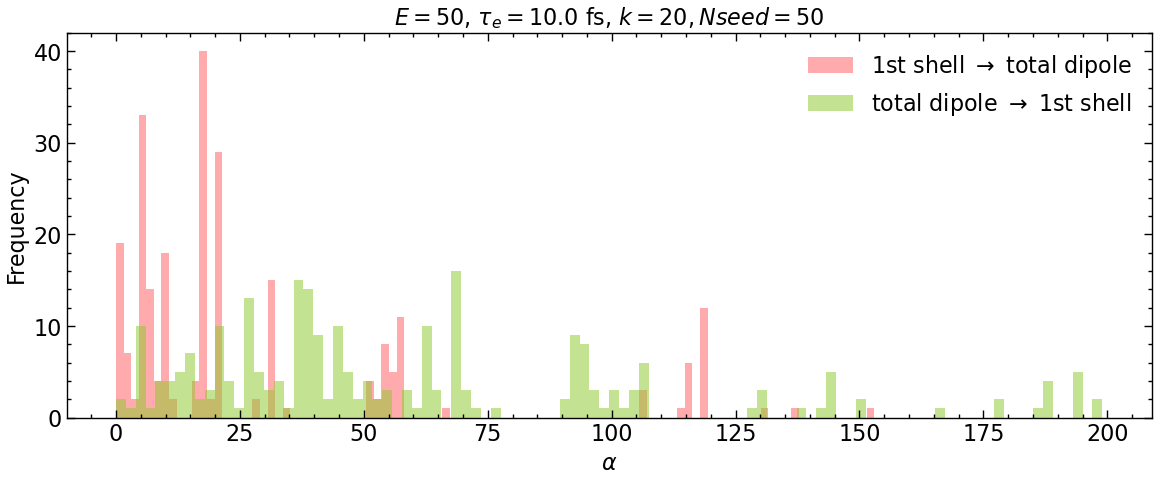

In [13]:
label_xy = "1st shell $\\rightarrow$ total dipole"
label_yx = "total dipole $\\rightarrow$ 1st shell"
label_yy = "total dipole $\\rightarrow$ total dipole"
label_xx = "1st shell $\\rightarrow$ 1st shell"


make_plot(info_imbalances_1st_to_total, info_imbalances_total_to_1st, label_xy, label_yx, label_yy, label_xx, nseed = len(seeds), name_tpl = "1st_total_300K_1B_ns")

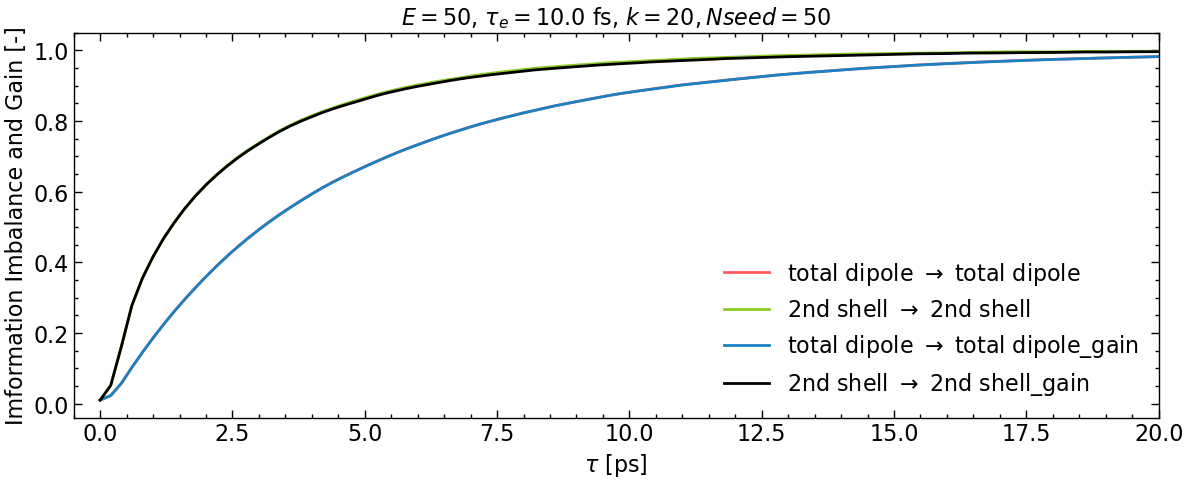

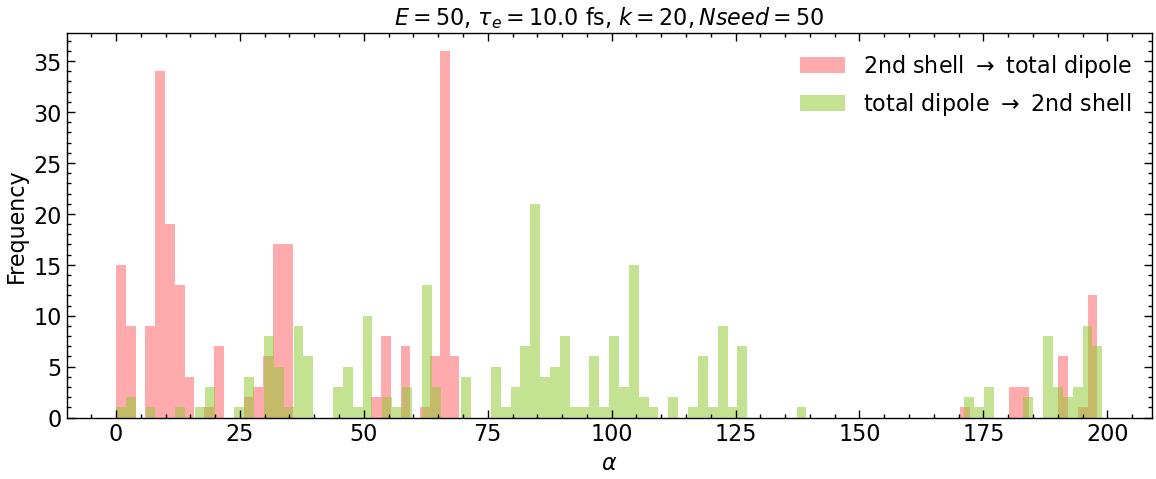

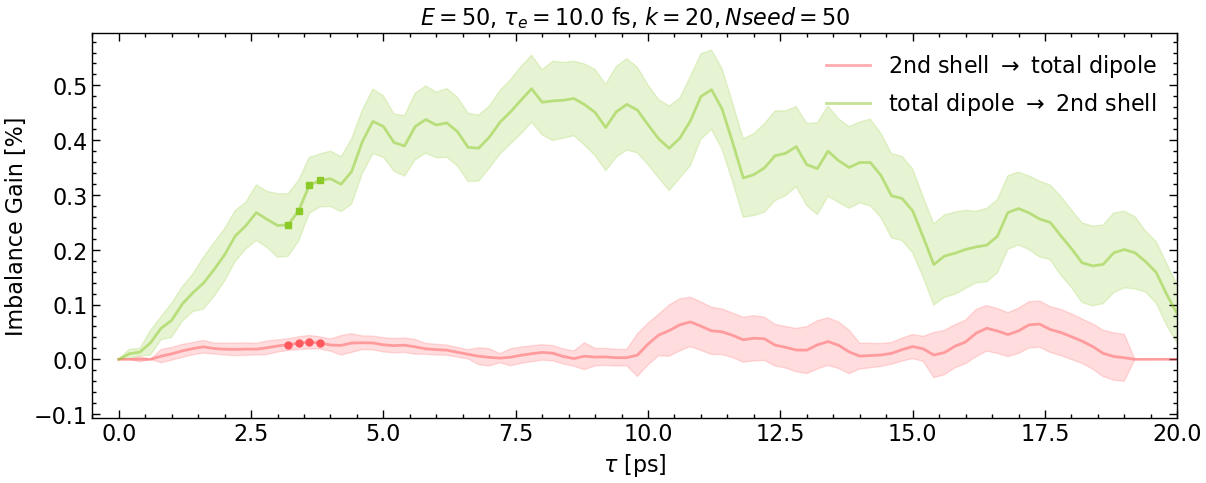

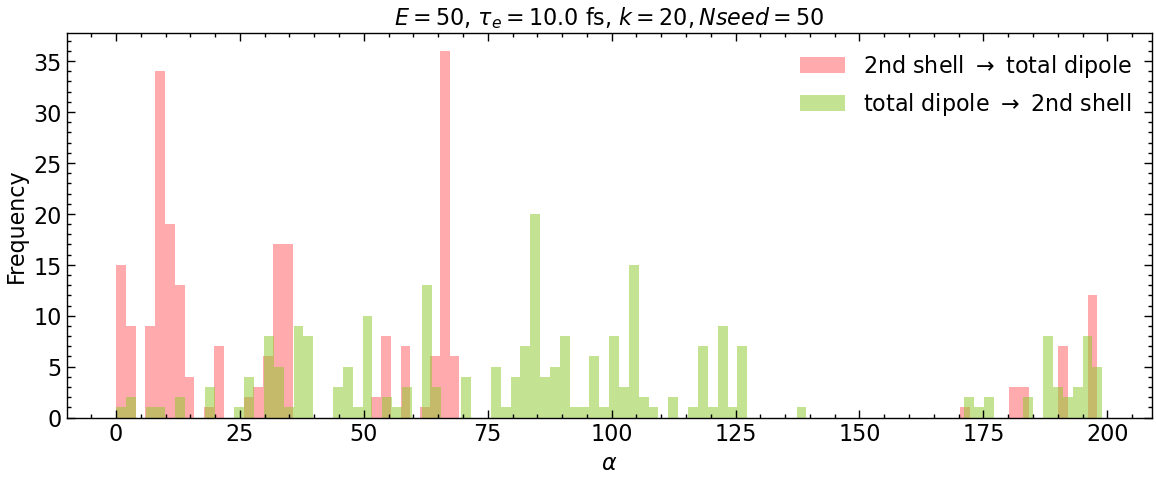

In [14]:
label_xy = "2nd shell $\\rightarrow$ total dipole"
label_yx = "total dipole $\\rightarrow$ 2nd shell"
label_yy = "total dipole $\\rightarrow$ total dipole"
label_xx = "2nd shell $\\rightarrow$ 2nd shell"


make_plot(info_imbalances_2nd_to_total, info_imbalances_total_to_2nd, label_xy, label_yx, label_yy, label_xx, nseed = len(seeds), name_tpl = "2nd_total_300K_1B_ns")